In [3]:
!pip install pandas transformers matplotlib seaborn torch scipy

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from scipy.special import softmax
import torch

# Load model
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("✅ Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully!


In [4]:
# 5 customer reviews for iCreativez
data = {
    'review_id': [1, 2, 3, 4, 5],
    'review': [
        "iCreativez delivered an amazing website for my business! The team was professional and the design exceeded my expectations.",
        "The mobile app development service was just okay. Communication could have been better, but the final product works fine.",
        "Absolutely terrible experience! The project was delayed by months and the customer support was unresponsive.",
        "Great service! They built a custom CRM that perfectly fits our needs. Highly recommend iCreativez for digital solutions.",
        "The logo design was decent, but I expected more creative options. Not bad, but not great either."
    ]
}

df = pd.DataFrame(data)
print("✅ Reviews loaded:")
df

✅ Reviews loaded:


,review_id,review
0,1,iCreativez delivered an amazing website for my...
1,2,The mobile app development service was just ok...
2,3,Absolutely terrible experience! The project wa...
3,4,Great service! They built a custom CRM that pe...
4,5,"The logo design was decent, but I expected mor..."


In [6]:
# Analyze sentiment function
def get_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    scores = outputs[0][0].detach().numpy()
    scores = softmax(scores)

    labels = ['Negative', 'Neutral', 'Positive']
    return {labels[i]: float(scores[i]) for i in range(3)}

# Apply to all reviews
df['scores'] = df['review'].apply(get_sentiment)
df['sentiment'] = df['scores'].apply(lambda x: max(x, key=x.get))

print("✅ Analysis complete!")
df[['review_id', 'review', 'sentiment']]

✅ Analysis complete!


,review_id,review,sentiment
0,1,iCreativez delivered an amazing website for my...,Positive
1,2,The mobile app development service was just ok...,Positive
2,3,Absolutely terrible experience! The project wa...,Negative
3,4,Great service! They built a custom CRM that pe...,Positive
4,5,"The logo design was decent, but I expected mor...",Neutral


In [7]:
# Show detailed results
print("\n" + "="*60)
print("SENTIMENT ANALYSIS RESULTS")
print("="*60)

for i, row in df.iterrows():
    print(f"\nReview {row['review_id']}:")
    print(f"Text: {row['review'][:80]}...")
    print(f"Sentiment: {row['sentiment']}")
    print(f"Confidence: {row['scores'][row['sentiment']]:.2%}")
    print("-"*40)


SENTIMENT ANALYSIS RESULTS

Review 1:
Text: iCreativez delivered an amazing website for my business! The team was profession...
Sentiment: Positive
Confidence: 98.78%
----------------------------------------

Review 2:
Text: The mobile app development service was just okay. Communication could have been ...
Sentiment: Positive
Confidence: 93.88%
----------------------------------------

Review 3:
Text: Absolutely terrible experience! The project was delayed by months and the custom...
Sentiment: Negative
Confidence: 95.44%
----------------------------------------

Review 4:
Text: Great service! They built a custom CRM that perfectly fits our needs. Highly rec...
Sentiment: Positive
Confidence: 98.23%
----------------------------------------

Review 5:
Text: The logo design was decent, but I expected more creative options. Not bad, but n...
Sentiment: Neutral
Confidence: 45.04%
----------------------------------------


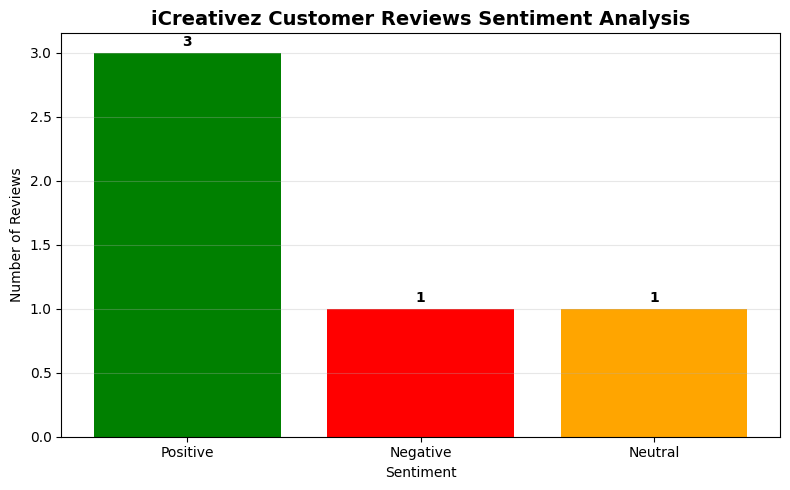


📊 SUMMARY:
Total Reviews: 5
✅ Positive: 3
⚪ Neutral: 1
❌ Negative: 1


In [8]:
# Create chart
sentiment_counts = df['sentiment'].value_counts()
colors = {'Positive': 'green', 'Neutral': 'orange', 'Negative': 'red'}

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values,
               color=[colors[x] for x in sentiment_counts.index])
plt.title('iCreativez Customer Reviews Sentiment Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.3)

# Add numbers on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print("\n📊 SUMMARY:")
print(f"Total Reviews: {len(df)}")
print(f"✅ Positive: {(df['sentiment'] == 'Positive').sum()}")
print(f"⚪ Neutral: {(df['sentiment'] == 'Neutral').sum()}")
print(f"❌ Negative: {(df['sentiment'] == 'Negative').sum()}")